<a href="https://colab.research.google.com/github/devendrasinghr284/NLP_Customer_Dispute_Prediction/blob/main/NYC_Taxi_Trip_Duration_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd

In [ ]:
import os
import zipfile
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv(r"/content/nyc_taxi_trip_duration.csv")

In [ ]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [ ]:
# "Dataset Shape"
print(df.shape)



(729322, 11)


In [ ]:
# collumn list
print(df.columns.tolist())

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


In [ ]:
# Data to info

In [ ]:
#info
print(df.info)

<bound method DataFrame.info of                id  vendor_id      pickup_datetime     dropoff_datetime  \
0       id1080784          2  2016-02-29 16:40:21  2016-02-29 16:47:01   
1       id0889885          1  2016-03-11 23:35:37  2016-03-11 23:53:57   
2       id0857912          2  2016-02-21 17:59:33  2016-02-21 18:26:48   
3       id3744273          2  2016-01-05 09:44:31  2016-01-05 10:03:32   
4       id0232939          1  2016-02-17 06:42:23  2016-02-17 06:56:31   
...           ...        ...                  ...                  ...   
729317  id3905982          2  2016-05-21 13:29:38  2016-05-21 13:34:34   
729318  id0102861          1  2016-02-22 00:43:11  2016-02-22 00:48:26   
729319  id0439699          1  2016-04-15 18:56:48  2016-04-15 19:08:01   
729320  id2078912          1  2016-06-19 09:50:47  2016-06-19 09:58:14   
729321  id1053441          2  2016-01-01 17:24:16  2016-01-01 17:44:40   

        passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  

In [ ]:
#Statistical summary

df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,729322,729322,id1053441,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vendor_id,729322.0,NaN,NaN,NaN,1.535403,0.498745,1.0,1.0,2.0,2.0,2.0
pickup_datetime,729322,709359,2016-03-03 10:48:41,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dropoff_datetime,729322,709308,2016-02-27 19:23:54,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passenger_count,729322.0,NaN,NaN,NaN,1.662055,1.312446,0.0,1.0,1.0,2.0,9.0
pickup_longitude,729322.0,NaN,NaN,NaN,-73.973513,0.069754,-121.933342,-73.991859,-73.981758,-73.967361,-65.897385
pickup_latitude,729322.0,NaN,NaN,NaN,40.750919,0.033594,34.712234,40.737335,40.75407,40.768314,51.881084
dropoff_longitude,729322.0,NaN,NaN,NaN,-73.973422,0.069588,-121.933304,-73.991318,-73.979759,-73.963036,-65.897385
dropoff_latitude,729322.0,NaN,NaN,NaN,40.751775,0.036037,32.181141,40.735931,40.754509,40.769741,43.921028
store_and_fwd_flag,729322,2,N,725282,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Missing values

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values = missing_values[missing_values > 0]


print("Missing values:")




Missing values:


In [ ]:
display(missing_values.to_frame("Missing_Count"))

,Missing_Count


In [ ]:
# Duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
#Data quality checks
print("Trip duration statistics:")

display(df["trip_duration"].describe())

print("\nMinimum trip duration:", df["trip_duration"].min())
print("Maximum trip duration:", df["trip_duration"].max())

print("\nNon-positive trip durations:")
print((df["trip_duration"] <= 0).sum())

Trip duration statistics:


,trip_duration
count,7.293220e+05
mean,9.522291e+02
std,3.864626e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.630000e+02
75%,1.075000e+03
max,1.939736e+06



Minimum trip duration: 1
Maximum trip duration: 1939736

Non-positive trip durations:
0


In [ ]:
# Passenger count check
print("Passenger count distribution:")
display(df["passenger_count"].value_counts().sort_index())

print("\nPassenger count <= 0:")
print((df["passenger_count"] <= 0).sum())

Passenger count distribution:


,count
passenger_count,
0,33
1,517415
2,105097
3,29692
4,14050
5,38926
6,24107
7,1
9,1



Passenger count <= 0:
33


In [ ]:
#6. Exploratory Data Analysis
plt.figure(figsize=(12, 6))
# limit extreme values for visualization

NameError: name 'plt' is not defined

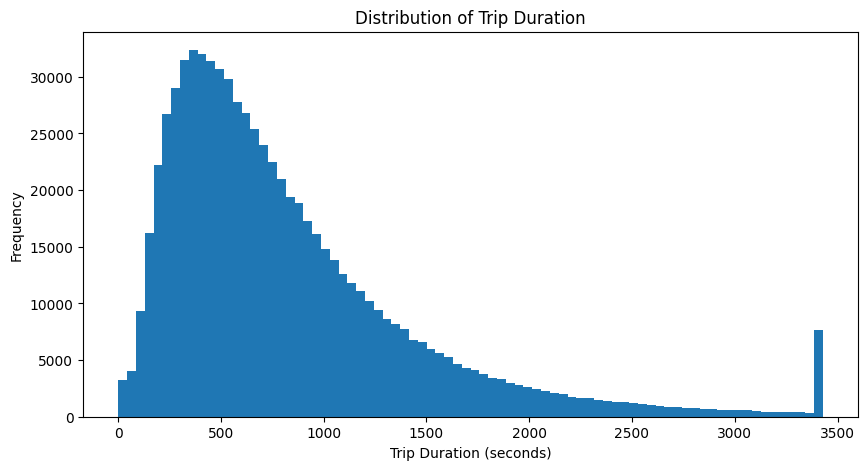

In [ ]:
plt.figure(figsize=(10, 5))

# Limit extreme values for visualization
upper_limit = df["trip_duration"].quantile(0.99)

plt.hist(
    df["trip_duration"].clip(upper=upper_limit),
    bins=80
)

plt.title("Distribution of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#7. Date and time analysis

df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_day"] = df["pickup_datetime"].dt.day
df["pickup_weekday"] = df["pickup_datetime"].dt.dayofweek
df["pickup_year"] = df["pickup_datetime"].dt.year

In [ ]:
df["pickup_month"] = df["pickup_datetime"].dt.month

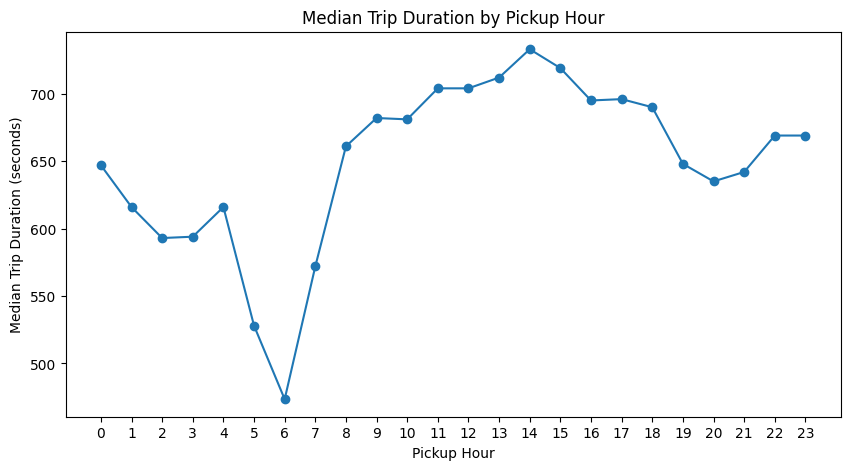

In [ ]:
#Trip duration by hour

hour_duration = (
    df.groupby("pickup_hour")["trip_duration"]
    .median()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hour_duration.index,
    hour_duration.values,
    marker="o"
)

plt.title("Median Trip Duration by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Median Trip Duration (seconds)")
plt.xticks(range(24))

plt.show()


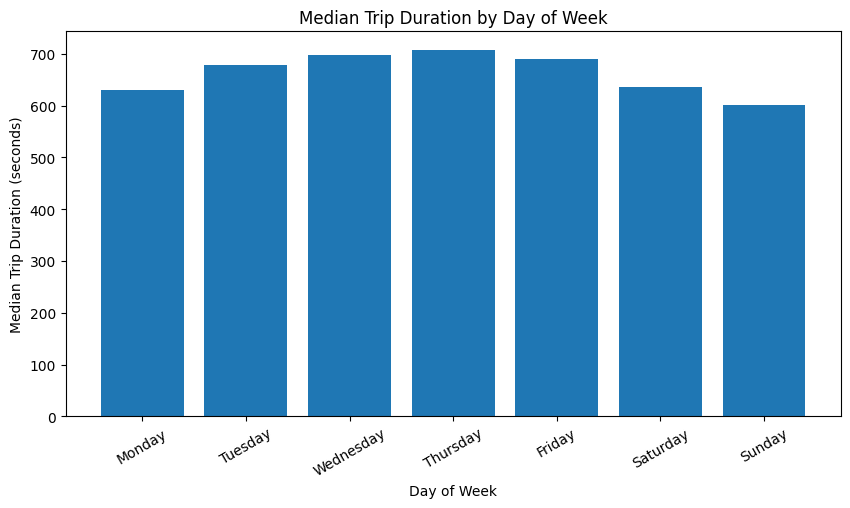

In [ ]:
#Trip duration by weekday


weekday_duration = (
    df.groupby("pickup_weekday")["trip_duration"]
    .median()
)

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_duration.index,
    weekday_duration.values
)

plt.title("Median Trip Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Trip Duration (seconds)")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"],
    rotation=30
)

plt.show()

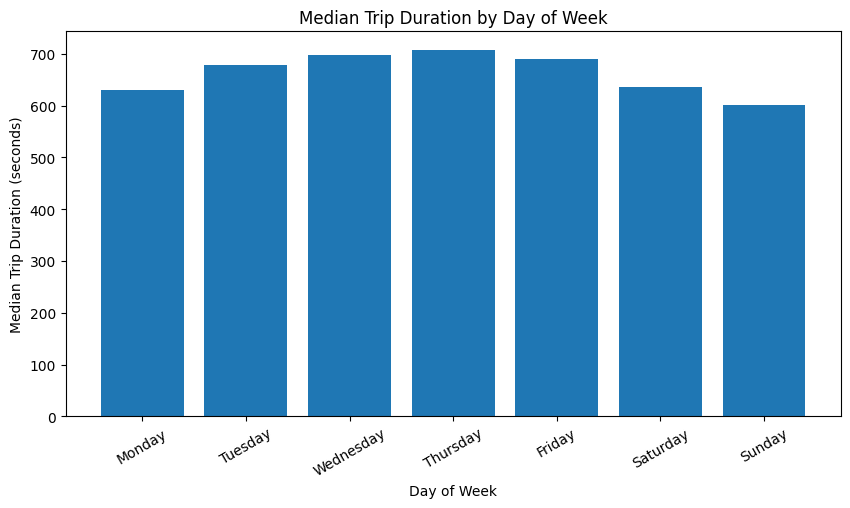

In [ ]:
#Cell 15 — Haversine distance function

weekday_duration = (
    df.groupby("pickup_weekday")["trip_duration"]
    .median()
)

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_duration.index,
    weekday_duration.values
)

plt.title("Median Trip Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Median Trip Duration (seconds)")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"],
    rotation=30
)

plt.show()

In [ ]:
#Create model features
def create_features(data):

    x = data.copy()

    # Convert datetime
    x["pickup_datetime"] = pd.to_datetime(
        x["pickup_datetime"]
    )

    # -------------------------
    # Date / Time Features
    # -------------------------

    x["pickup_hour"] = x["pickup_datetime"].dt.hour

    x["pickup_minute"] = (
        x["pickup_datetime"].dt.minute
    )

    x["pickup_day"] = (
        x["pickup_datetime"].dt.day
    )

    x["pickup_weekday"] = (
        x["pickup_datetime"].dt.dayofweek
    )

    x["pickup_month"] = (
        x["pickup_datetime"].dt.month
    )

    x["pickup_year"] = (
        x["pickup_datetime"].dt.year
    )

    x["pickup_weekofyear"] = (
        x["pickup_datetime"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    # Weekend
    x["is_weekend"] = (
        x["pickup_weekday"] >= 5
    ).astype(int)

    # Rush hour
    x["is_rush_hour"] = (
        x["pickup_hour"]
        .isin([7, 8, 9, 17, 18, 19])
        .astype(int)
    )

    # -------------------------
    # Cyclical Time Features
    # -------------------------

    x["hour_sin"] = np.sin(
        2 * np.pi * x["pickup_hour"] / 24
    )

    x["hour_cos"] = np.cos(
        2 * np.pi * x["pickup_hour"] / 24
    )

    x["weekday_sin"] = np.sin(
        2 * np.pi * x["pickup_weekday"] / 7
    )

    x["weekday_cos"] = np.cos(
        2 * np.pi * x["pickup_weekday"] / 7
    )

    # -------------------------
    # Distance Features
    # -------------------------

    x["distance_km"] = haversine_km(
        x["pickup_longitude"],
        x["pickup_latitude"],
        x["dropoff_longitude"],
        x["dropoff_latitude"]
    )

    x["delta_longitude"] = (
        x["dropoff_longitude"]
        - x["pickup_longitude"]
    )

    x["delta_latitude"] = (
        x["dropoff_latitude"]
        - x["pickup_latitude"]
    )

    x["manhattan_like_distance"] = (
        x["delta_longitude"].abs()
        + x["delta_latitude"].abs()
    )

    # -------------------------
    # Store and Forward Flag
    # -------------------------

    x["store_and_fwd_flag"] = (
        x["store_and_fwd_flag"]
        .map({"N": 0, "Y": 1})
        .fillna(0)
        .astype(int)
    )

    # -------------------------
    # Remove Leakage / IDs
    # -------------------------

    columns_to_remove = [
        "id",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_duration"
    ]

    feature_columns = [
        col
        for col in x.columns
        if col not in columns_to_remove
    ]

    return x[feature_columns]

In [ ]:
def haversine_km(lon1, lat1, lon2, lat2):

    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    distance = (
        2
        * 6371.0088
        * np.arcsin(np.sqrt(a))
    )

    return distance

In [ ]:
#Generate X and y

X = create_features(df)

y = df["trip_duration"].astype(float)

print("Feature matrix shape:", X.shape)

print("\nFeatures:")
print(X.columns.tolist())

display(X.head())



Feature matrix shape: (729322, 24)

Features:
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'pickup_hour', 'pickup_day', 'pickup_weekday', 'pickup_year', 'pickup_month', 'pickup_minute', 'pickup_weekofyear', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'distance_km', 'delta_longitude', 'delta_latitude', 'manhattan_like_distance']


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,pickup_hour,pickup_day,pickup_weekday,pickup_year,pickup_month,pickup_minute,pickup_weekofyear,is_weekend,is_rush_hour,hour_sin,hour_cos,weekday_sin,weekday_cos,distance_km,delta_longitude,delta_latitude,manhattan_like_distance
0,2,1,-73.953918,40.778873,-73.963875,40.771164,0,16,29,0,2016,2,40,9,0,0,-0.866025,-5.000000e-01,0.000000,1.000000,1.199074,-0.009956,-0.007710,0.017666
1,1,2,-73.988312,40.731743,-73.994751,40.694931,0,23,11,4,2016,3,35,10,0,0,-0.258819,9.659258e-01,-0.433884,-0.900969,4.129117,-0.006439,-0.036812,0.043251
2,2,2,-73.997314,40.721458,-73.948029,40.774918,0,17,21,6,2016,2,59,7,1,1,-0.965926,-2.588190e-01,-0.781831,0.623490,7.250763,0.049286,0.053459,0.102745
3,2,6,-73.961670,40.759720,-73.956779,40.780628,0,9,5,1,2016,1,44,1,0,1,0.707107,-7.071068e-01,0.781831,0.623490,2.361101,0.004890,0.020908,0.025799
4,1,1,-74.017120,40.708469,-73.988182,40.740631,0,6,17,2,2016,2,42,7,0,0,1.000000,6.123234e-17,0.974928,-0.222521,4.328540,0.028938,0.032162,0.061100


In [ ]:
#9. Check the engineered data
#Cell 18 — Check missing values

print("Missing values in X:")

display(
    X.isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)


Missing values in X:


,Missing
vendor_id,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0
pickup_hour,0
pickup_day,0
pickup_weekday,0


In [ ]:
#Cell 19 — Check infinite values

print(
    "Infinite values:",
    np.isinf(X.select_dtypes(include=np.number)).sum().sum()
)

Infinite values: 0


In [ ]:
#10. Train-Test Split
#Cell 20 — Split data


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (583457, 24)
Testing data: (145865, 24)


In [ ]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [ ]:
#12. Baseline Model

baseline_prediction = np.full(
    len(y_test),
    y_train.median()
)

baseline_rmsle = np.sqrt(
    mean_squared_error(
        np.log1p(y_test),
        np.log1p(baseline_prediction)
    )
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print("Baseline RMSLE:", round(baseline_rmsle, 4))
print("Baseline MAE:", round(baseline_mae, 2), "seconds")

Baseline RMSLE: 0.1138
Baseline MAE: 0.61 seconds


In [ ]:
#Cell 23 — Train the model

model = HistGradientBoostingRegressor(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    l2_regularization=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
# Make prediction
pred_log = model.predict(X_test)

# Convert back from log scale
pred_seconds = np.expm1(pred_log)

# Ensure prediction cannot be negative
pred_seconds = np.maximum(
    0,
    pred_seconds
)

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")

display(
    pd.DataFrame({
        "Actual": y_test.values[:10],
        "Predicted": pred_seconds[:10]
    })
)

Predictions generated successfully.

First 10 predictions:


,Actual,Predicted
0,6.489205,468.903320
1,5.278115,254.412808
2,6.734592,1242.355185
3,5.988961,409.023706
4,6.526495,860.938479
5,6.632002,945.794286
6,5.288267,189.639958
7,6.773080,751.746415
8,6.927558,821.739026
9,6.383507,677.158220


In [ ]:
#Model Evaluation

rmsle = np.sqrt(
    mean_squared_error(
        np.log1p(y_test),
        np.log1p(pred_seconds)
    )
)

print("RMSLE:", round(rmsle, 4))

RMSLE: 4.5004


In [ ]:
# Calculate addition metrics

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_seconds
    )
)

mae = mean_absolute_error(
    y_test,
    pred_seconds
)

r2 = r2_score(
    y_test,
    pred_seconds
)

print("RMSLE:", round(rmsle, 4))

print(
    "RMSE:",
    round(rmse, 2),
    "seconds"
)

print(
    "RMSE:",
    round(rmse / 60, 2),
    "minutes"
)

print(
    "MAE:",
    round(mae, 2),
    "seconds"
)

print(
    "MAE:",
    round(mae / 60, 2),
    "minutes"
)

print(
    "R²:",
    round(r2, 4)
)

RMSLE: 4.5004
RMSE: 974.81 seconds
RMSE: 16.25 minutes
MAE: 793.39 seconds
MAE: 13.22 minutes
R²: -1503133.6734


In [ ]:
#Model Performance Summary

results = pd.DataFrame({
    "Metric": [
        "Baseline RMSLE",
        "Model RMSLE",
        "Model RMSE (seconds)",
        "Model MAE (seconds)",
        "Model R2"
    ],

    "Value": [
        baseline_rmsle,
        rmsle,
        rmse,
        mae,
        r2
    ]
})

display(results)

,Metric,Value
0,Baseline RMSLE,1.137547e-01
1,Model RMSLE,4.500352e+00
2,Model RMSE (seconds),9.748091e+02
3,Model MAE (seconds),7.933934e+02
4,Model R2,-1.503134e+06


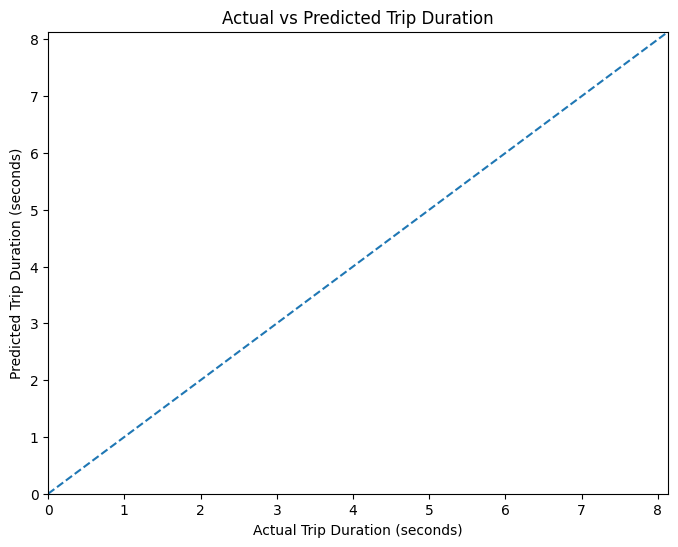

In [ ]:
#17. Actual vs Predicted

sample_size = min(
    5000,
    len(y_test)
)

random_state = np.random.RandomState(42)

sample_indices = random_state.choice(
    len(y_test),
    sample_size,
    replace=False
)

actual_sample = y_test.iloc[
    sample_indices
]

prediction_sample = pred_seconds[
    sample_indices
]

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_sample,
    prediction_sample,
    alpha=0.25,
    s=8
)

limit = np.percentile(
    y_test,
    99
)

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.plot(
    [0, limit],
    [0, limit],
    linestyle="--"
)

plt.xlabel(
    "Actual Trip Duration (seconds)"
)

plt.ylabel(
    "Predicted Trip Duration (seconds)"
)

plt.title(
    "Actual vs Predicted Trip Duration"
)

plt.show()

In [ ]:
#Error Analysis

error_df = pd.DataFrame({
    "Actual_Duration": y_test.values,
    "Predicted_Duration": pred_seconds
})

error_df["Absolute_Error"] = (
    abs(
        error_df["Actual_Duration"]
        - error_df["Predicted_Duration"]
    )
)

display(
    error_df
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(20)
)

,Actual_Duration,Predicted_Duration,Absolute_Error
14597,8.075894,4779.519447,4771.443553
87208,8.339262,4733.416781,4725.077519
57437,8.250620,4725.908820,4717.658200
64349,8.473659,4710.596385,4702.122726
116405,8.507345,4709.647767,4701.140423
15590,8.611412,4698.297256,4689.685844
33305,8.585973,4696.105861,4687.519888
133389,8.563886,4693.961512,4685.397626
1038,8.840725,4637.527261,4628.686536
88271,8.560253,4632.578458,4624.018205


In [ ]:
#19. Feature Importance

# Use a smaller sample to make calculation faster
sample_size = min(
    5000,
    len(X_test)
)

sample_indices = np.random.RandomState(
    42
).choice(
    len(X_test),
    sample_size,
    replace=False
)

X_importance = X_test.iloc[
    sample_indices
]

y_importance = y_test.iloc[
    sample_indices
]

permutation = permutation_importance(
    model,
    X_importance,
    y_importance,
    scoring="neg_root_mean_squared_error",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.Series(
    permutation.importances_mean,
    index=X_importance.columns
)

feature_importance = (
    feature_importance
    .sort_values(ascending=False)
)

display(
    feature_importance
    .head(15)
    .to_frame("Importance")
)

,Importance
distance_km,0.557969
hour_cos,0.035866
delta_longitude,0.033264
dropoff_latitude,0.031522
pickup_hour,0.020316
delta_latitude,0.017833
dropoff_longitude,0.015000
pickup_longitude,0.013052
pickup_latitude,0.009967
hour_sin,0.009889


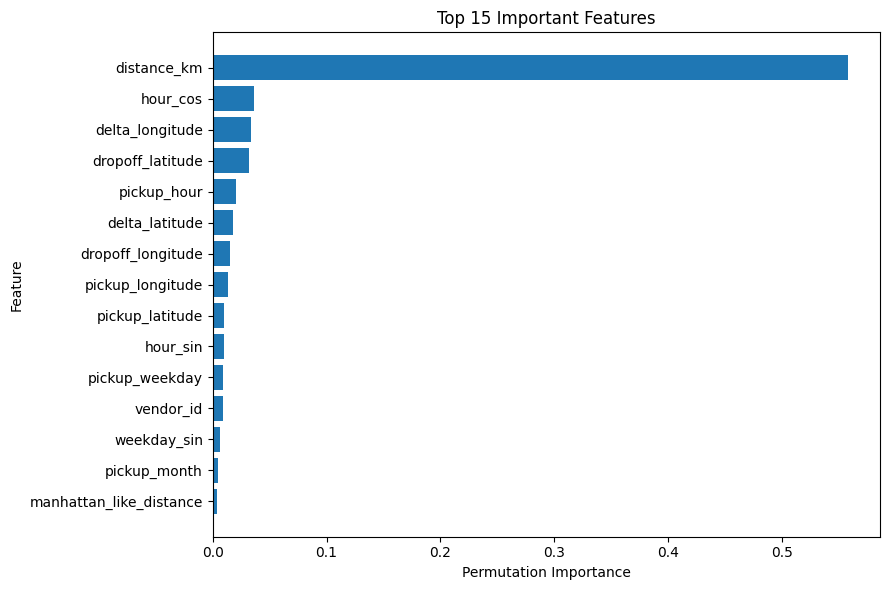

In [ ]:
#Feature importance visualization

top_features = (
    feature_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features.index,
    top_features.values
)

plt.xlabel(
    "Permutation Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.tight_layout()

plt.show()

In [ ]:
#Prediction example

prediction_example = pd.DataFrame({
    "Actual_Trip_Duration_Seconds": y_test.values[:20],
    "Predicted_Trip_Duration_Seconds": pred_seconds[:20]
})

prediction_example["Actual_Minutes"] = (
    prediction_example[
        "Actual_Trip_Duration_Seconds"
    ] / 60
)

prediction_example["Predicted_Minutes"] = (
    prediction_example[
        "Predicted_Trip_Duration_Seconds"
    ] / 60
)

display(prediction_example)

,Actual_Trip_Duration_Seconds,Predicted_Trip_Duration_Seconds,Actual_Minutes,Predicted_Minutes
0,6.489205,468.903320,0.108153,7.815055
1,5.278115,254.412808,0.087969,4.240213
2,6.734592,1242.355185,0.112243,20.705920
3,5.988961,409.023706,0.099816,6.817062
4,6.526495,860.938479,0.108775,14.348975
5,6.632002,945.794286,0.110533,15.763238
6,5.288267,189.639958,0.088138,3.160666
7,6.773080,751.746415,0.112885,12.529107
8,6.927558,821.739026,0.115459,13.695650
9,6.383507,677.158220,0.106392,11.285970


In [ ]:
#Final Conclusion